In [1]:
%pip install torch torchvision --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys, cv2 as cv, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

print(f"torch      {torch.__version__}")
print(f"torchvision {torchvision.__version__}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device:    {DEVICE}")

SRC_DIR = Path("data/raw/easy")

# Class mapping — 0 is always background in Faster R-CNN
CLASSES = ["__background__", "treble", "slip_stitch", "chain", "double"]
CLS2IDX = {c: i for i, c in enumerate(CLASSES)}

torch      2.11.0
torchvision 0.26.0
device:    cpu


In [3]:
# ── Preprocessing pipeline (full image — no triangle crop) ───────────────────
# For detection we use the WHOLE image so the model can learn spatial context.

def get_contours(img_path, min_area=30, max_area=50000):
    """Run the OpenCV pipeline and return (gray_image, list_of_contours)."""
    img  = cv.imread(str(img_path))
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    _, thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    thresh_inv = cv.bitwise_not(thresh)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
    closed = cv.morphologyEx(thresh_inv, cv.MORPH_CLOSE, kernel)

    contours, _ = cv.findContours(closed, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    contours = [c for c in contours if min_area < cv.contourArea(c) < max_area]
    contours = _remove_contained(contours)
    return gray, contours


def _remove_contained(contours):
    boxes = [cv.boundingRect(c) for c in contours]
    drop  = set()
    for i, (xi, yi, wi, hi) in enumerate(boxes):
        for j, (xj, yj, wj, hj) in enumerate(boxes):
            if i != j and xi <= xj and yi <= yj and xi+wi >= xj+wj and yi+hi >= yj+hj:
                drop.add(i); break
    return [c for i, c in enumerate(contours) if i not in drop]


# Preview: show how many contours are found per image without the triangle mask
print(f"{'Image':<12} {'Contours':>10}")
print("-" * 25)
for p in sorted(SRC_DIR.glob("*.png")):
    _, cs = get_contours(p)
    print(f"{p.name:<12} {len(cs):>10}")

Image          Contours
-------------------------
12.png              131
13.png               75
14.png               73
2.png                63
20.png              358
21.png              358
22.png              286
26.png              202
3.png                60


In [4]:
# ── Generate pseudo-annotations using the SVM classifier ─────────────────────
# We use the already-trained SVM (from baseline_ml.ipynb) to label every
# contour bbox in every image. This gives us (image, boxes, labels) triples
# that serve as training signal for Faster R-CNN.
#
# Note: these are pseudo-labels — the SVM may mis-classify some symbols.
# Once you have proper hand-labeled box annotations you can replace this.

sys.path.insert(0, ".")
from classifier import SymbolClassifier

clf = SymbolClassifier.load("model.joblib")
print(f"Classifier loaded. Classes: {list(clf.label_encoder.classes_)}")

PADDING = 4

def build_annotations(img_path):
    """
    Returns a dict with:
        image_rgb : (H, W, 3) uint8 array
        boxes     : list of [x1, y1, x2, y2] in pixel coords
        labels    : list of int class indices (matching CLASSES)
    """
    img  = cv.imread(str(img_path))
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    gray_full, contours = get_contours(img_path)

    boxes, labels = [], []
    h_img, w_img = gray.shape

    for c in contours:
        x, y, w, h = cv.boundingRect(c)
        x1 = max(x - PADDING, 0);  y1 = max(y - PADDING, 0)
        x2 = min(x + w + PADDING, w_img); y2 = min(y + h + PADDING, h_img)
        crop  = gray[y1:y2, x1:x2]
        label = clf.predict(crop)
        if label not in CLS2IDX:
            continue
        boxes.append([x, y, x + w, y + h])   # x1,y1,x2,y2 format for Faster R-CNN
        labels.append(CLS2IDX[label])

    return {
        "image_rgb": cv.cvtColor(img, cv.COLOR_BGR2RGB),
        "boxes":     boxes,
        "labels":    labels,
    }

# Build annotations for every image
all_annotations = {}
for p in sorted(SRC_DIR.glob("*.png")):
    ann = build_annotations(p)
    all_annotations[p] = ann
    counts = {c: ann["labels"].count(CLS2IDX[c]) for c in CLASSES[1:]}
    print(f"{p.name:<12}  boxes={len(ann['boxes'])}  {counts}")

Classifier loaded. Classes: [np.str_('chain'), np.str_('double'), np.str_('noise'), np.str_('slip_stitch'), np.str_('treble')]
12.png        boxes=77  {'treble': 45, 'slip_stitch': 32, 'chain': 0, 'double': 0}
13.png        boxes=29  {'treble': 18, 'slip_stitch': 11, 'chain': 0, 'double': 0}
14.png        boxes=46  {'treble': 36, 'slip_stitch': 10, 'chain': 0, 'double': 0}
2.png         boxes=41  {'treble': 32, 'slip_stitch': 9, 'chain': 0, 'double': 0}
20.png        boxes=164  {'treble': 46, 'slip_stitch': 118, 'chain': 0, 'double': 0}
21.png        boxes=176  {'treble': 44, 'slip_stitch': 103, 'chain': 25, 'double': 4}
22.png        boxes=134  {'treble': 85, 'slip_stitch': 49, 'chain': 0, 'double': 0}
26.png        boxes=143  {'treble': 16, 'slip_stitch': 127, 'chain': 0, 'double': 0}
3.png         boxes=18  {'treble': 3, 'slip_stitch': 12, 'chain': 0, 'double': 3}


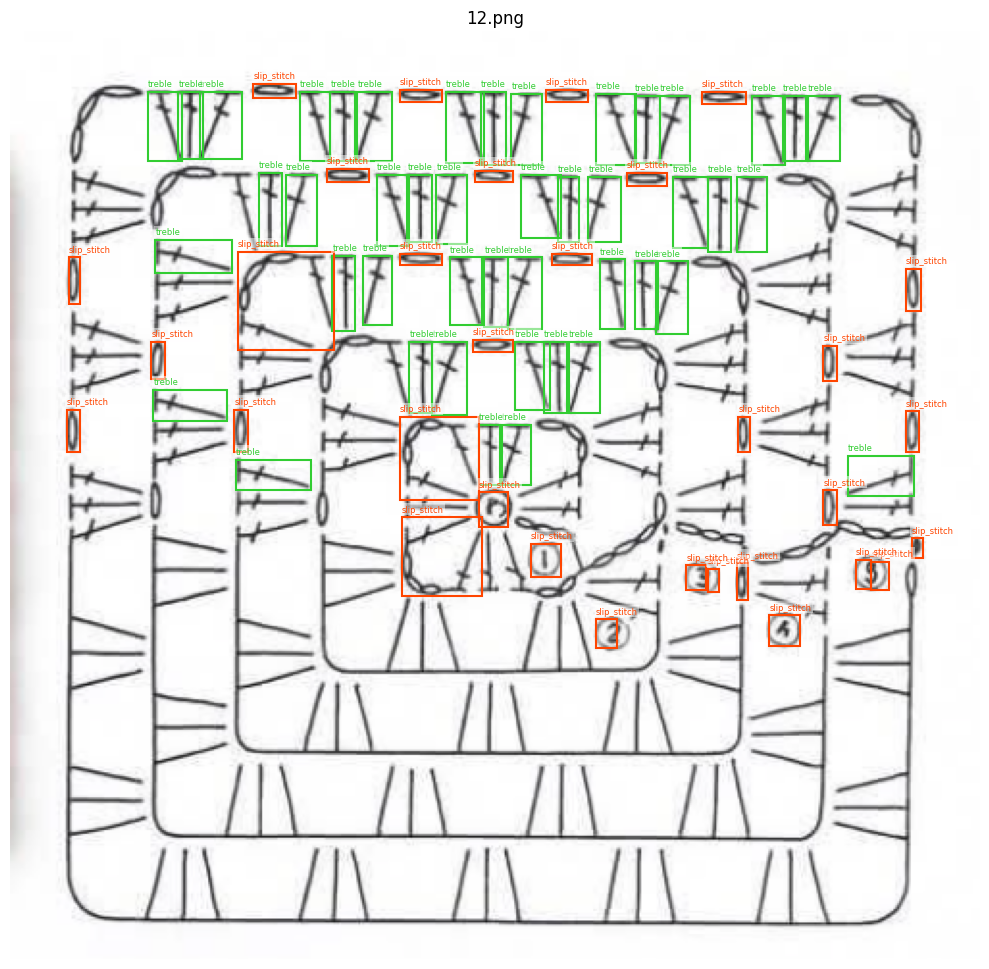

In [5]:
# ── Visualise annotations on one image ───────────────────────────────────────
COLORS = {"treble": "limegreen", "slip_stitch": "orangered",
          "chain": "dodgerblue", "double": "violet"}

def show_annotations(ann, title=""):
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(ann["image_rgb"])
    for box, lbl_idx in zip(ann["boxes"], ann["labels"]):
        x1, y1, x2, y2 = box
        cls   = CLASSES[lbl_idx]
        color = COLORS.get(cls, "grey")
        rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=1.5, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 3, cls, color=color, fontsize=6,
                bbox=dict(facecolor="white", alpha=0.5, pad=1, edgecolor="none"))
    ax.set_title(title or f"{len(ann['boxes'])} annotations")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# Show the first image
first_path = sorted(SRC_DIR.glob("*.png"))[0]
show_annotations(all_annotations[first_path], title=first_path.name)

In [6]:
# ── PyTorch Dataset ───────────────────────────────────────────────────────────

class CrochetDataset(Dataset):
    """
    Wraps the pre-built annotations dict into a torchvision-compatible dataset.

    Each item returns:
        image  : FloatTensor (3, H, W), values in [0, 1]
        target : dict with 'boxes' (N,4) and 'labels' (N,) tensors
    """

    def __init__(self, annotations: dict):
        self.items = list(annotations.items())   # [(Path, ann_dict), ...]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, ann = self.items[idx]

        # Image → float tensor (3, H, W) in [0, 1]
        image = torch.as_tensor(ann["image_rgb"], dtype=torch.float32)
        image = image.permute(2, 0, 1) / 255.0

        # Boxes and labels
        boxes  = torch.as_tensor(ann["boxes"],  dtype=torch.float32)
        labels = torch.as_tensor(ann["labels"], dtype=torch.int64)

        # Faster R-CNN requires boxes shaped (N, 4); handle empty case
        if boxes.ndim == 1:
            boxes = boxes.unsqueeze(0)

        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx])}
        return image, target


# Train / val split (leave last 2 images for validation)
paths      = sorted(all_annotations.keys())
train_anns = {p: all_annotations[p] for p in paths[:-2]}
val_anns   = {p: all_annotations[p] for p in paths[-2:]}

train_ds = CrochetDataset(train_anns)
val_ds   = CrochetDataset(val_anns)

print(f"Train: {len(train_ds)} images  |  Val: {len(val_ds)} images")


def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, collate_fn=collate_fn)

Train: 7 images  |  Val: 2 images


In [7]:
# ── Model: Faster R-CNN with ResNet-50 FPN backbone ──────────────────────────
# We start from COCO pretrained weights and replace only the box predictor
# head so it outputs our number of classes. This way the backbone feature
# extractor is already trained on natural images and we only fine-tune the
# detection head on our crochet data.

def build_model(num_classes):
    """
    num_classes includes background, e.g. 5 for
    [background, treble, slip_stitch, chain, double].
    """
    # Load pretrained backbone + RPN
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

    # Replace the classification head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


model = build_model(num_classes=len(CLASSES))
model.to(DEVICE)

# Freeze the backbone — only train the RPN and detection head
# (important with small datasets to avoid overfitting)
for name, param in model.named_parameters():
    if "backbone" in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /Users/elevchenko/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100.0%


Trainable params: 14,515,240 / 41,314,536  (35.1%)


In [8]:
# ── Training loop ─────────────────────────────────────────────────────────────

NUM_EPOCHS = 10
LR         = 0.005

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR, momentum=0.9, weight_decay=1e-4
)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history = {"train_loss": []}

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for images, targets in train_loader:
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss      = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    lr_scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    history["train_loss"].append(avg_loss)
    print(f"Epoch {epoch:>2}/{NUM_EPOCHS}  loss={avg_loss:.4f}")

print("\nTraining complete.")

Epoch  1/10  loss=5.4723
Epoch  2/10  loss=3.3586
Epoch  3/10  loss=2.2828
Epoch  4/10  loss=1.8213
Epoch  5/10  loss=1.8040
Epoch  6/10  loss=1.7132
Epoch  7/10  loss=1.5660
Epoch  8/10  loss=1.4455
Epoch  9/10  loss=1.4392
Epoch 10/10  loss=1.3873

Training complete.


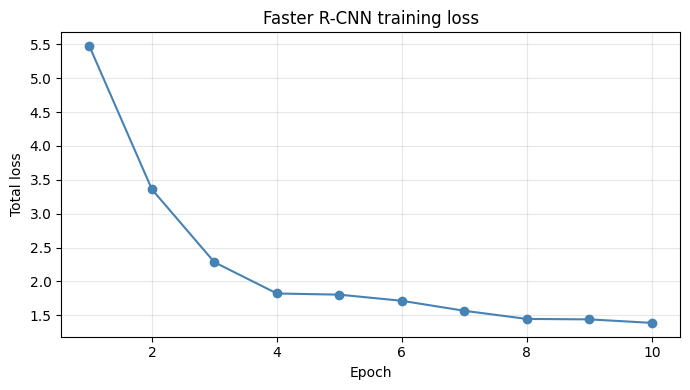

In [9]:
# ── Loss curve ────────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(range(1, NUM_EPOCHS + 1), history["train_loss"], marker="o", color="steelblue")
plt.xlabel("Epoch"); plt.ylabel("Total loss")
plt.title("Faster R-CNN training loss")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Detections above threshold: 100


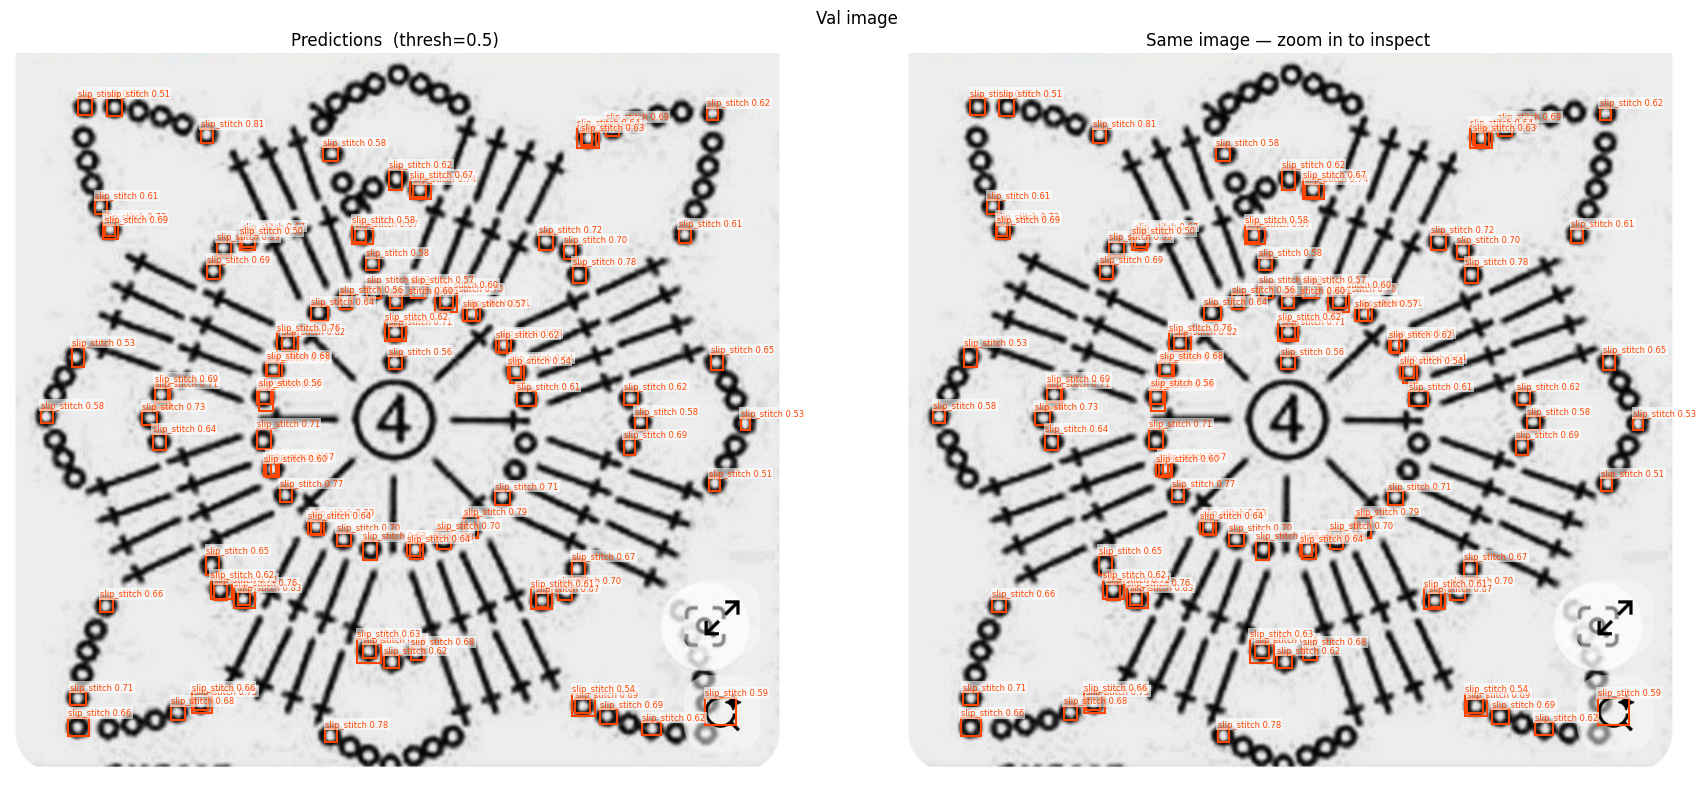

Detections above threshold: 34


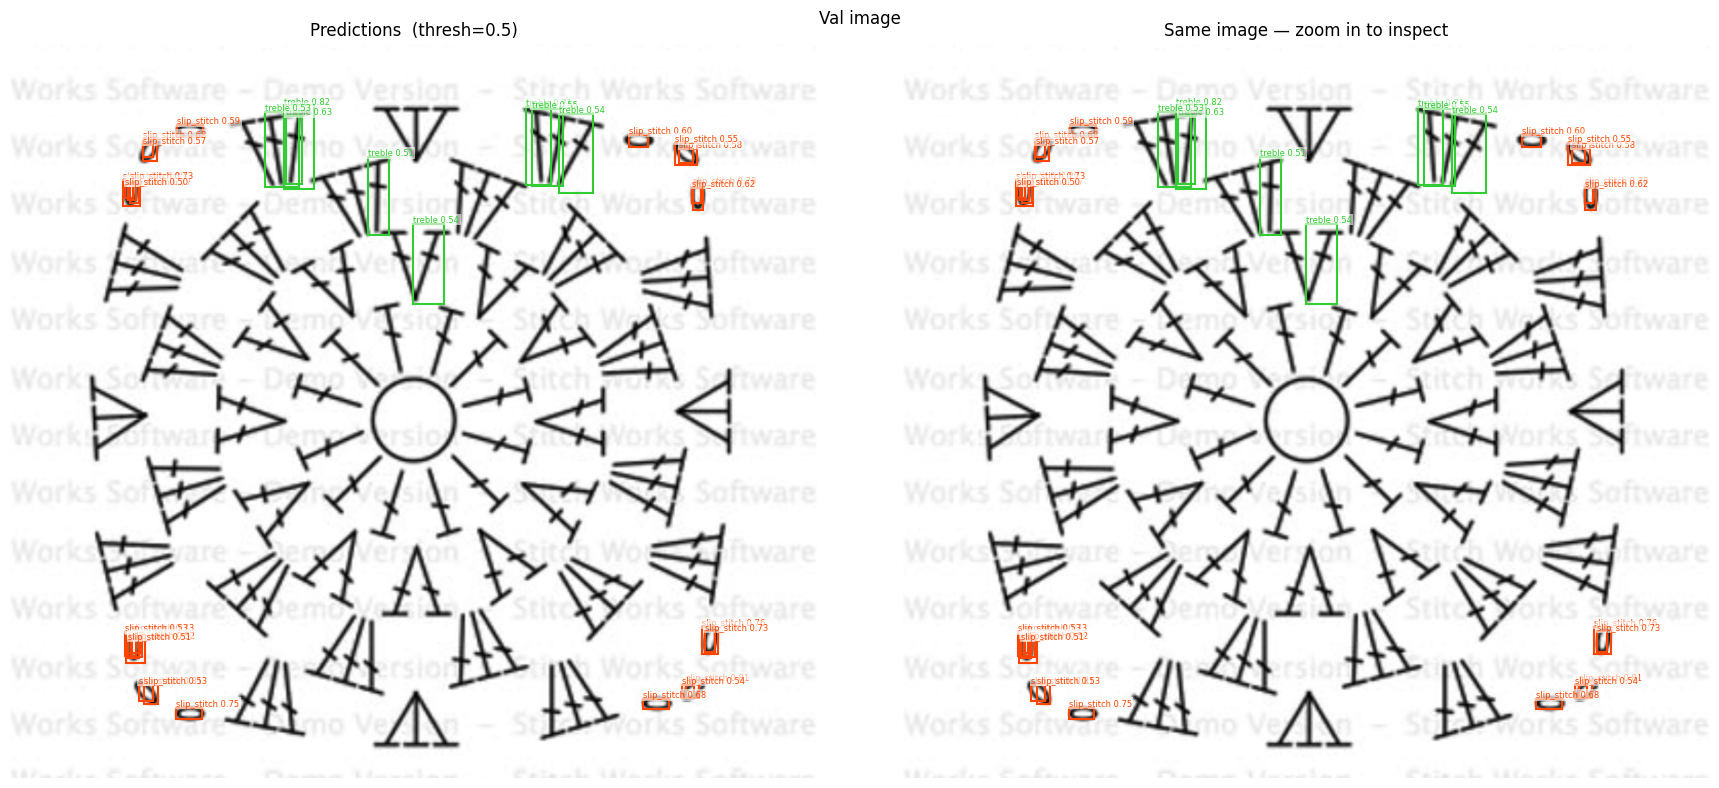

In [10]:
# ── Inference on validation images ───────────────────────────────────────────

SCORE_THRESHOLD = 0.5   # discard predictions below this confidence

def predict(model, img_tensor):
    """Run inference on a single (3, H, W) float tensor. Returns detections dict."""
    model.eval()
    with torch.no_grad():
        outputs = model([img_tensor.to(DEVICE)])
    return outputs[0]


def show_predictions(img_rgb, predictions, score_thresh=SCORE_THRESHOLD, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    for ax, (boxes, labels, scores, label_src) in zip(axes, [
        (predictions["boxes"].cpu(), predictions["labels"].cpu(),
         predictions["scores"].cpu(), "Faster R-CNN"),
    ] * 2):
        ax.imshow(img_rgb)
        for box, lbl, score in zip(boxes, labels, scores):
            if score < score_thresh:
                continue
            x1, y1, x2, y2 = box.tolist()
            cls   = CLASSES[lbl.item()]
            color = COLORS.get(cls, "grey")
            rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=1.5, edgecolor=color, facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, y1 - 3, f"{cls} {score:.2f}", color=color, fontsize=6,
                    bbox=dict(facecolor="white", alpha=0.6, pad=1, edgecolor="none"))
        ax.set_title(label_src); ax.axis("off")

    axes[0].set_title(f"Predictions  (thresh={score_thresh})")
    axes[1].set_title("Same image — zoom in to inspect")
    plt.suptitle(title, fontsize=12)
    plt.tight_layout(); plt.show()


# Run on all validation images
for img_tensor, target in val_loader:
    img_t    = img_tensor[0]
    img_rgb  = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    preds    = predict(model, img_t)
    kept     = (preds["scores"] >= SCORE_THRESHOLD).sum().item()
    print(f"Detections above threshold: {kept}")
    show_predictions(img_rgb, preds, title=f"Val image")

In [11]:
# ── Save model ────────────────────────────────────────────────────────────────
torch.save(model.state_dict(), "faster_rcnn.pth")
print("Model saved to faster_rcnn.pth")

# ── Reload example ────────────────────────────────────────────────────────────
# model = build_model(num_classes=len(CLASSES))
# model.load_state_dict(torch.load("faster_rcnn.pth", map_location=DEVICE))
# model.to(DEVICE)

Model saved to faster_rcnn.pth
